# SentAI - Analyse Approfondie (Donnees et Modele)

Ce notebook est votre outil unique pour comprendre le dataset et valider l'architecture de l'IA.
Il suit les regles d'or du ML (regle 2 : connaitre ses donnees, regle 13 : gerer le desequilibre).

Objectifs :
1. Verifier que l'environnement virtuel (.venv) est correctement utilise.
2. Analyser statistiquement la repartition des classes (Type 1, 2, 3).
3. Inspecter visuellement la qualite et la resolution des images.
4. Valider le chargement du modele EfficientNet-B4.

## 1. Configuration et Environnement
On s'assure d'utiliser les bonnes bibliotheques (torch, timm, pandas).

In [1]:
import os
import sys
from pathlib import Path

# Detection de la racine du projet et de l'environnement virtuel
ROOT = Path(os.getcwd()).parent.parent.resolve()
VENV_SITE = Path(os.getcwd()).parent / ".venv" / "Lib" / "site-packages"

if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
if VENV_SITE.exists() and str(VENV_SITE) not in sys.path: sys.path.insert(0, str(VENV_SITE))

import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import timm

print(f"Projet detecte a : {ROOT}")
print(f"PyTorch disponible : {torch.__version__}")
print(f"Timm disponible : {timm.__version__}")


c:\AI\Machine Learning\SentAI\ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Projet detecte a : C:\AI\Machine Learning\SentAI
PyTorch disponible : 2.10.0+cpu
Timm disponible : 0.9.12


## 2. Analyse des Donnees
Nous chargeons le fichier splits.csv genere lors de la preparation.

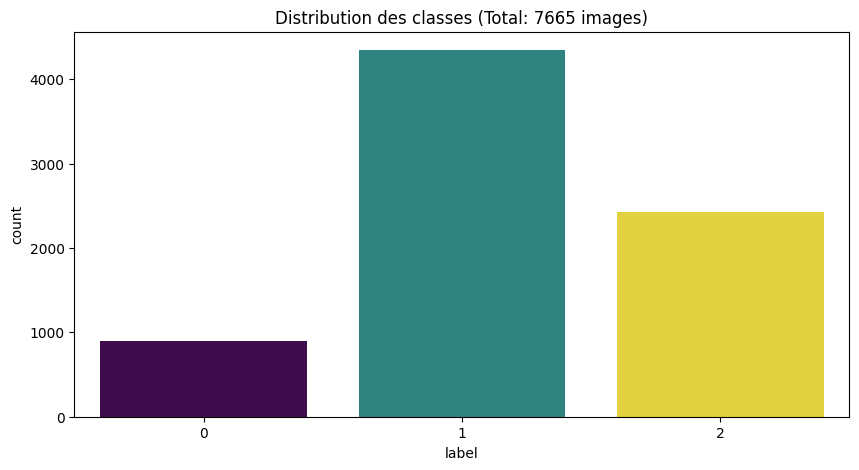

--- Repartition ---
Type 1 : 11.7%
Type 2 : 56.7%
Type 3 : 31.7%


In [2]:
# Chargement du listing des images
csv_path = ROOT / 'ml/data/interim/splits.csv'

if not csv_path.exists():
    print("ERREUR : splits.csv introuvable. Executez prepare_dataset.py.")
else:
    df = pd.read_csv(csv_path)
    total = len(df)

    dist = df['label'].value_counts(normalize=True) * 100

    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x='label', hue='label', palette='viridis', legend=False)
    plt.title(f"Distribution des classes (Total: {total} images)")
    plt.show()

    print('--- Repartition ---')
    print(f"Type 1 : {dist.get(0, 0):.1f}%")
    print(f"Type 2 : {dist.get(1, 0):.1f}%")
    print(f"Type 3 : {dist.get(2, 0):.1f}%")

## 3. Analyse de la Resolution
L'IA a besoin d'images standardisees. Voyons les tailles reelles des images.

In [3]:
def analyze_res(path):
    # Utilisation d'un chemin relatif adapte
    img_path = ROOT / 'ml' / path
    img = cv2.imread(str(img_path))
    return img.shape if img is not None else None

# Echantillonnage de 30 images pour test rapide
sample = df.sample(30)
sample['res'] = sample['path'].apply(analyze_res)

print('Resolutions detectees sur l\'echantillon :')
print(sample['res'].value_counts())
print('Note : Le pipeline redimensionnera toutes les images en 384x384.')

Resolutions detectees sur l'echantillon :
res
(224, 224, 3)    30
Name: count, dtype: int64
Note : Le pipeline redimensionnera toutes les images en 384x384.


## 4. Inspection Visuelle
Affichage d'une image de chaque classe pour valider les etiquettes.

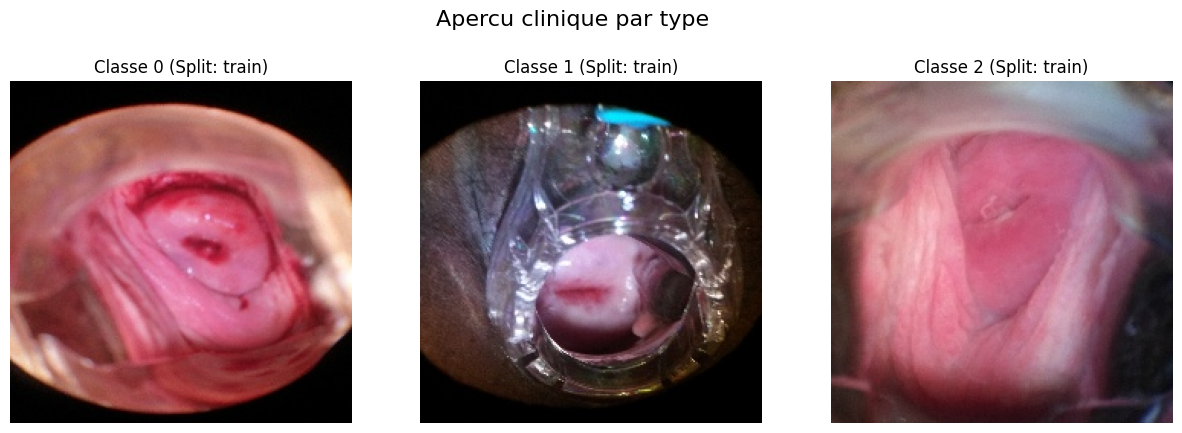

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(3):
    subset = df[df['label'] == i]
    if not subset.empty:
        row = subset.iloc[0]
        img_path = ROOT / 'ml' / row['path']
        img = cv2.imread(str(img_path))
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].set_title(f"Classe {i} (Split: {row['split']})")
        else:
            axes[i].set_title(f"Erreur lecture Classe {i}")
    axes[i].axis('off')

plt.suptitle('Apercu clinique par type', fontsize=16)
plt.show()

## 5. Le Coeur de l'IA (EfficientNet-B4)
Test du chargement du modele depuis le code source.

In [4]:
from ml.src.models.efficientnet import build_model

cfg_model = {
    'model': {
        'architecture': 'efficientnet_b4',
        'num_classes': 3,
        'pretrained': True
    }
}

model = build_model(cfg_model)
params = sum(p.numel() for p in model.parameters())

print(f"Modele charge : {cfg_model['model']['architecture']}")
print(f"Nombre total de parametres a entrainer : {params:,}")

Modele charge : efficientnet_b4
Nombre total de parametres a entrainer : 17,553,995


### Conclusion de l'analyse
1. Environnement : torch et timm sont disponibles.
2. Donnees : la distribution a ete analysee ci-dessus.
3. Action : vous pouvez maintenant passer au notebook d'entrainement ou a la ligne de commande.